In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
import warnings
warnings.filterwarnings('ignore')

<h1>UK ROAD ACCIDENT DATA ANALYSIS</h1>
<h2>INCLUSIVE YEAR 2019 - 2022</h2>
<h3>Analyst: James Patrick I. De Mesa</h3>

In [2]:
accident = pd.read_csv("datasets//accident_data.csv")

In [3]:
accident

,Index,Accident_Severity,Accident Date,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200701BS64157,Serious,05/06/2019,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car
1,200701BS65737,Serious,02/07/2019,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car
2,200701BS66127,Serious,26/08/2019,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,NaN,Urban,NaN,Taxi/Private hire car
3,200701BS66128,Serious,16/08/2019,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats)
4,200701BS66837,Slight,03/09/2019,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,NaN,Urban,NaN,Other vehicle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660674,201091NM01760,Slight,18/02/2022,57.374005,Daylight,Highland,-3.467828,2,1,Dry,Single carriageway,Rural,Fine no high winds,Car
660675,201091NM01881,Slight,21/02/2022,57.232273,Darkness - no lighting,Highland,-3.809281,1,1,Frost or ice,Single carriageway,Rural,Fine no high winds,Car
660676,201091NM01935,Slight,23/02/2022,57.585044,Daylight,Highland,-3.862727,1,3,Frost or ice,Single carriageway,Rural,Fine no high winds,Car
660677,201091NM01964,Serious,23/02/2022,57.214898,Darkness - no lighting,Highland,-3.823997,1,2,Wet or damp,Single carriageway,Rural,Fine no high winds,Motorcycle over 500cc


In [4]:
accident.describe()

,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles
count,660654.000000,660653.000000,660679.000000,660679.000000
mean,52.553866,-1.431210,1.357040,1.831255
std,1.406922,1.383330,0.824847,0.715269
min,49.914430,-7.516225,1.000000,1.000000
25%,51.490690,-2.332291,1.000000,1.000000
50%,52.315641,-1.411667,1.000000,2.000000
75%,53.453452,-0.232869,1.000000,2.000000
max,60.757544,1.762010,68.000000,32.000000


In [5]:
accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    660679 non-null  object 
 1   Accident_Severity        660679 non-null  object 
 2   Accident Date            660679 non-null  object 
 3   Latitude                 660654 non-null  float64
 4   Light_Conditions         660679 non-null  object 
 5   District Area            660679 non-null  object 
 6   Longitude                660653 non-null  float64
 7   Number_of_Casualties     660679 non-null  int64  
 8   Number_of_Vehicles       660679 non-null  int64  
 9   Road_Surface_Conditions  659953 non-null  object 
 10  Road_Type                656159 non-null  object 
 11  Urban_or_Rural_Area      660664 non-null  object 
 12  Weather_Conditions       646551 non-null  object 
 13  Vehicle_Type             660679 non-null  object 
dtypes: f

In [6]:
accident['Latitude'] = accident['Latitude'].fillna(accident['Latitude'].mode()[0])
accident['Longitude'] = accident['Longitude'].fillna(accident['Longitude'].mode()[0])
accident['Road_Surface_Conditions'] = accident['Road_Surface_Conditions'].fillna('unknown road conditions')
accident['Road_Type'] = accident['Road_Type'].fillna('unaccounted')
accident['Weather_Conditions'] = accident['Weather_Conditions'].fillna('unaccounted')
accident['Urban_or_Rural_Area'] = accident['Urban_or_Rural_Area'].fillna(accident['Urban_or_Rural_Area'].mode()[0])

In [7]:
for col in["Accident_Severity","Latitude", "Light_Conditions", "District Area", 
           "Longitude", "Road_Surface_Conditions", "Road_Type", "Urban_or_Rural_Area",
          "Weather_Conditions", "Vehicle_Type"]:
    accident[col] = accident[col].astype('category')

accident['Accident Date'] = pd.to_datetime(accident['Accident Date'], dayfirst = True, errors = "coerce")

In [8]:
accident.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
dtype: int64

In [9]:
accident['Year'] = accident["Accident Date"].dt.year
accident['Month'] = accident["Accident Date"].dt.month
accident['Day'] = accident["Accident Date"].dt.day
accident['DayofWeek'] = accident["Accident Date"].dt.dayofweek

<h1 style="color:red">Insight No. 1</h1>
<h2 style="color:blue">What road type has the highest fatal accident?</h2>
<h3>The highest fatal accident in a road is in a single carriageway</h3>

In [91]:
road_serverity = accident.groupby(["Road_Type", "Accident_Severity"]).size().reset_index()

In [95]:
road_serverity.unstack()

Road_Type          0       Dual carriageway
                   1       Dual carriageway
                   2       Dual carriageway
                   3         One way street
                   4         One way street
                   5         One way street
                   6             Roundabout
                   7             Roundabout
                   8             Roundabout
                   9     Single carriageway
                   10    Single carriageway
                   11    Single carriageway
                   12             Slip road
                   13             Slip road
                   14             Slip road
                   15           unaccounted
                   16           unaccounted
                   17           unaccounted
Accident_Severity  0                  Fatal
                   1                Serious
                   2                 Slight
                   3                  Fatal
                   4            

In [97]:
road_serverity_wo_slight =  accident["Accident_Severity"] != "Slight"

In [100]:
road_severity_road_type = road_serverity_wo_slight.groupby(["Accident_Severity", "Road_Type"]).size()

KeyError: 'Accident_Severity'

<h1 style="color:red">Insight No. 2</h1>
<h2 style="color:blue">In which area has the higher number of accidents?</h2>
<h3>The Urban has the higher number of accidents than Rural</h3>

In [61]:
accident_area = accident["Urban_or_Rural_Area"].value_counts()

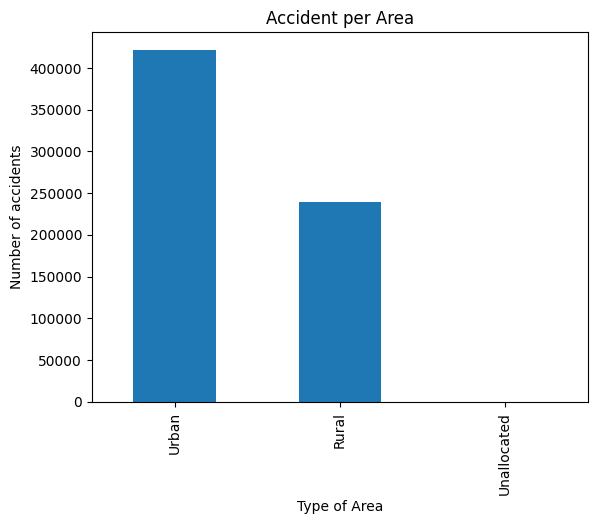

In [64]:
accident_area.plot(kind="bar")
plt.title("Accident per Area")
plt.xlabel("Type of Area")
plt.ylabel("Number of accidents")
plt.show()

<h1 style="color:red">Insight No. 3</h1>
<h2 style="color:blue">What is the average number of casualties? </h2>
<h3>The average number of casualties is 1.4 </h3>

In [13]:
avg_casualties = np.round(accident['Number_of_Casualties'].mean(), 1)

In [14]:
avg_casualties

np.float64(1.4)

<h1 style="color:red">Insight No. 4</h1>
<h2 style="color:blue">What is the average number of vehicles in an accident? </h2>
<h3>The average number of vehicles in an accident is 1.8 </h3>

In [15]:
avg_vehicles = np.round(accident['Number_of_Vehicles'].mean(), 1)

In [16]:
avg_vehicles

np.float64(1.8)

<h1 style="color:red">Insight No. 5</h1>
<h2 style="color:blue">What is the most common accident severity ? </h2>
<h3>The most common accident severity is 'Slight'</h3>

In [17]:
avg_severity = accident['Accident_Severity'].mode()[0]

In [18]:
avg_severity

'Slight'

<h1 style="color:red">Insight No. 6</h1>
<h2 style="color:blue">In which area has the has the higher number of casualties?</h2>
<h3>Urban area has a higher number of casualties</h3>

In [19]:
area_casualties = accident.groupby('Urban_or_Rural_Area')['Number_of_Casualties'].sum()

In [83]:
area_casualties

Urban_or_Rural_Area
Rural          353515
Unallocated        13
Urban          543040
Name: Number_of_Casualties, dtype: int64

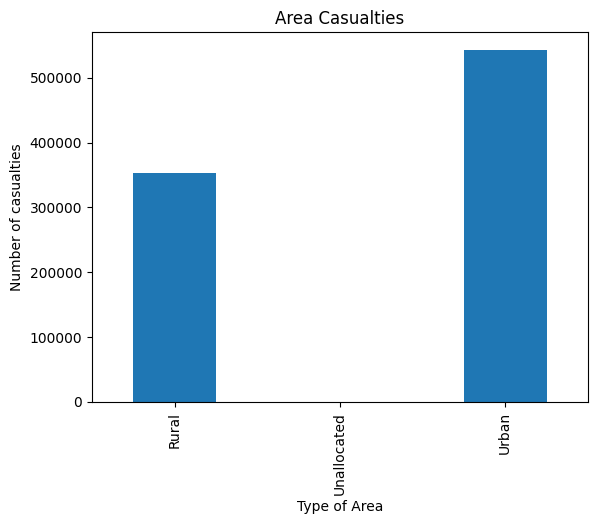

In [85]:
area_casualties.plot(kind="bar")
plt.title("Area Casualties")
plt.xlabel("Type of Area")
plt.ylabel("Number of casualties")
plt.show()

<h1 style="color:red">Insight No. 7</h1>
<h2 style="color:blue">On which light conditions has the highest number of accident?</h2>
<h3>On Daylight has the highest number of accidents</h3>

In [21]:
lightCdt_accidents = accident['Light_Conditions'].value_counts()

In [22]:
lightCdt_accidents

Light_Conditions
Daylight                       484880
Darkness - lights lit          129335
Darkness - no lighting          37437
Darkness - lighting unknown      6484
Darkness - lights unlit          2543
Name: count, dtype: int64

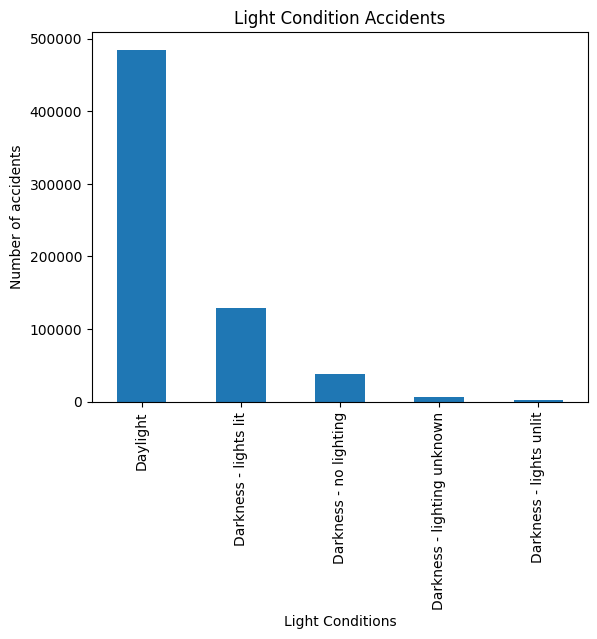

In [82]:
lightCdt_accidents.plot(kind="bar")
plt.title("Light Condition Accidents")
plt.xlabel("Light Conditions")
plt.ylabel("Number of accidents")
plt.show()

<h1 style="color:red">Insight No. 8</h1>
<h2 style="color:blue">On which weather conditions has the highest number of accident?</h2>
<h3>Fine no high winds has the highest number of accidents</h3>

In [23]:
weatherCdt_accidents = accident['Weather_Conditions'].value_counts()

In [24]:
weatherCdt_accidents

Weather_Conditions
Fine no high winds       520885
Raining no high winds     79696
Other                     17150
unaccounted               14128
Raining + high winds       9615
Fine + high winds          8554
Snowing no high winds      6238
Fog or mist                3528
Snowing + high winds        885
Name: count, dtype: int64

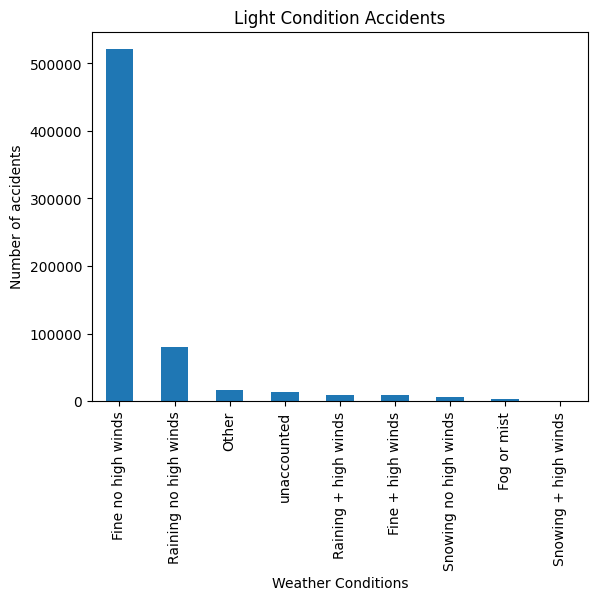

In [90]:
weatherCdt_accidents.plot(kind="bar")
plt.title("Light Condition Accidents")
plt.xlabel("Weather Conditions")
plt.ylabel("Number of accidents")
plt.show()

<h1 style="color:red">Insight No. 9</h1>
<h2 style="color:blue">What road type has the highest number of accident?</h2>
<h3>The road type that has the highest accident is the single carriageway</h3>

In [25]:
roadtype_accidents = accident['Road_Type'].value_counts()

In [26]:
roadtype_accidents

Road_Type
Single carriageway    492143
Dual carriageway       99424
Roundabout             43992
One way street         13559
Slip road               7041
unaccounted             4520
Name: count, dtype: int64

<h1 style="color:red">Insight No. 10</h1>
<h2 style="color:blue">What road surface conditions has the highest number of accident?</h2>
<h3>The road surface conditions that has the highest accident is a dry surface.</h3>

In [27]:
roadsurface_accidents = accident['Road_Surface_Conditions'].value_counts()

In [28]:
roadsurface_accidents

Road_Surface_Conditions
Dry                        447821
Wet or damp                186708
Frost or ice                18517
Snow                         5890
Flood over 3cm. deep         1017
unknown road conditions       726
Name: count, dtype: int64

<h1 style="color:red">Insight No. 11</h1>
<h2 style="color:blue">What is the average number of casualties for each level of severity?</h2>
<h3>The average number of casualties for fatal accidents is 1.9, for the serious is 1.5 , and for the slight is 1.3.</h3>

In [29]:
avg_casualties_per_severity = np.round(accident.groupby('Accident_Severity')['Number_of_Casualties'].mean(), 1)

In [30]:
avg_casualties_per_severity

Accident_Severity
Fatal      1.9
Serious    1.5
Slight     1.3
Name: Number_of_Casualties, dtype: float64

<h1 style="color:red">Insight No. 12</h1>
<h2 style="color:blue">What is the average number of casualties in the urban, rural and unallocated areas?</h2>
<h3>The average number of casualties for rural area accidents is 1.5, for the urban area is 1.3 , and for unallocated areas is 1.2.</h3>

In [31]:
avg_casualties_per_area = np.round(accident.groupby('Urban_or_Rural_Area')['Number_of_Casualties'].mean(), 1)

In [32]:
avg_casualties_per_area

Urban_or_Rural_Area
Rural          1.5
Unallocated    1.2
Urban          1.3
Name: Number_of_Casualties, dtype: float64

<h1 style="color:red">Insight No. 13</h1>
<h2 style="color:blue">What is the average number of casualties in each weather conditions?</h2>
<h3>TFine with no winds, fine with high winds, raining with high winds, raining with no winds, snowing with high winds, and other weather conditions have an average of 1.4 casualties, then snowing with no high winds has an average of 1.3 casualties, while fog or mist has 1.5 casualties.</h3>

In [33]:
avg_casualties_per_weather = np.round(accident.groupby('Weather_Conditions')['Number_of_Casualties'].mean(), 1)

In [34]:
avg_casualties_per_weather

Weather_Conditions
Fine + high winds        1.4
Fine no high winds       1.4
Fog or mist              1.5
Other                    1.4
Raining + high winds     1.4
Raining no high winds    1.4
Snowing + high winds     1.4
Snowing no high winds    1.3
unaccounted              1.2
Name: Number_of_Casualties, dtype: float64

<h1 style="color:red">Insight No. 14</h1>
<h2 style="color:blue">In which road area has the higher number of accidents?</h2>
<h3>Urban roads have a higher accidents than roads in rural areas.</h3>

In [35]:
accidents_per_area_road = accident.groupby(['Urban_or_Rural_Area', 'Road_Type']).size().unstack().T

In [36]:
accidents_per_area_road

Urban_or_Rural_Area,Rural,Unallocated,Urban
Road_Type,,,
Dual carriageway,48715,1,50708
One way street,1193,0,12366
Roundabout,15545,1,28446
Single carriageway,168010,9,324124
Slip road,4294,0,2747
unaccounted,1233,0,3287


<h1 style="color:red">Insight No. 15</h1>
<h2 style="color:blue">Which combinations of weather and light conditions result in the highest number of casualties?</h2>
<h3>Daylight and fine with no high winds have the highest number of casualties.</h3>

In [37]:
casualties_by_weather_light = accident.groupby(['Weather_Conditions', 'Light_Conditions'])['Number_of_Casualties'].sum().unstack()

In [38]:
casualties_by_weather_light

Light_Conditions,Darkness - lighting unknown,Darkness - lights lit,Darkness - lights unlit,Darkness - no lighting,Daylight
Weather_Conditions,,,,,
Fine + high winds,82,2543,75,1213,7943
Fine no high winds,4903,125686,2251,38800,531805
Fog or mist,89,1323,48,1267,2399
Other,234,6535,177,2824,13466
Raining + high winds,147,4185,115,2173,7001
Raining no high winds,808,31563,620,9538,69700
Snowing + high winds,21,354,7,247,626
Snowing no high winds,119,2411,37,1129,4674
unaccounted,2068,2508,55,524,12275


<h1 style="color:red">Insight No. 16</h1>
<h2 style="color:blue">Does having more vehicles involve results to more casualties?</h2>
<h3>No, having more vehicles doesn't mean more casualties.</h3>
<h3>The number of vehicles has no correlation with the number of casualties</h3>

In [39]:
vehicles_casualties_corr = accident['Number_of_Vehicles'].corr(accident['Number_of_Casualties'])

In [40]:
vehicles_casualties_corr

np.float64(0.22888886126927557)

<h1 style="color:red">Insight No. 17</h1>
<h2 style="color:blue">What vehicle type has the highest number of accidents</h2>
<h3>A car has the highest number of accidents</h3>

In [41]:
vehicletype_accidents = accident['Vehicle_Type'].value_counts()

In [42]:
vehicletype_accidents

Vehicle_Type
Car                                      497992
Van / Goods 3.5 tonnes mgw or under       34160
Bus or coach (17 or more pass seats)      25878
Motorcycle over 500cc                     25657
Goods 7.5 tonnes mgw and over             17307
Motorcycle 125cc and under                15269
Taxi/Private hire car                     13294
Motorcycle over 125cc and up to 500cc      7656
Motorcycle 50cc and under                  7603
Goods over 3.5t. and under 7.5t            6096
Other vehicle                              5637
Minibus (8 - 16 passenger seats)           1976
Agricultural vehicle                       1947
Pedal cycle                                 197
Data missing or out of range                  6
Ridden horse                                  4
Name: count, dtype: int64

<h1 style="color:red">Insight No. 18</h1>
<h2 style="color:blue">What district area has the highest number of accidents</h2>
<h3>Birmingham has the highest number of accidents</h3>

In [43]:
districtarea_accidents = accident['District Area'].value_counts()

In [44]:
districtarea_accidents

District Area
Birmingham            13491
Leeds                  8898
Manchester             6720
Bradford               6212
Sheffield              5710
                      ...  
Berwick-upon-Tweed      153
Teesdale                142
Shetland Islands        133
Orkney Islands          117
Clackmannanshire         91
Name: count, Length: 422, dtype: int64

<h1 style="color:red">Insight No. 19</h1>
<h2 style="color:blue">Which district area has the highest average number of casualties?</h2>
<h3>Blaeu Gwent has the highest average number of casualties</h3>

In [45]:
avg_casualties_per_district = np.round(accident.groupby('District Area')['Number_of_Casualties'].mean(), 1).sort_values(ascending = False)

In [46]:
avg_casualties_per_district

District Area
Blaeu Gwent                1.7
Merthyr Tydfil             1.6
North East Lincolnshire    1.6
Blaenau Gwent              1.6
Teesdale                   1.6
                          ... 
Kensington and Chelsea     1.1
Hammersmith and Fulham     1.1
City of London             1.1
Camden                     1.1
Aberdeen City              1.1
Name: Number_of_Casualties, Length: 422, dtype: float64

<h1 style="color:red">Insight No. 20</h1>
<h2 style="color:blue">Do different road surface conditions impact the number of casualties?</h2>
<h3>The road surface conditions impact the number of casualties</h3>
<h3>There is correlation between road surface condtions and number of casualties</h3>

In [47]:
dry = accident[accident['Road_Surface_Conditions'] == 'Dry']['Number_of_Casualties']
wet = accident[accident['Road_Surface_Conditions'] == 'Wet or damp']['Number_of_Casualties']
f_stat, p_value = f_oneway(dry, wet)
print(p_value)

1.5774597323918563e-247


<h1 style="color:red">Insight No. 21</h1>
<h2 style="color:blue">Do urban vs. rural areas have different numbers of vehicles involved?</h2>
<h3>Yes, they have different numbers of vehicles involved in an accident</h3>
<h3>There is correlation between urban vs. rural areas and numbers of vehicles involved</h3>

In [48]:
urban = accident[accident['Urban_or_Rural_Area'] == 'Urban']['Number_of_Vehicles']
rural = accident[accident['Urban_or_Rural_Area'] == 'Rural']['Number_of_Vehicles']
f_stat, p_value = f_oneway(urban, rural)
print(p_value)

9.09607802972544e-198


In [49]:
accident

,Index,Accident_Severity,Accident Date,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Year,Month,Day,DayofWeek
0,200701BS64157,Serious,2019-06-05,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car,2019,6,5,2
1,200701BS65737,Serious,2019-07-02,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car,2019,7,2,1
2,200701BS66127,Serious,2019-08-26,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,unaccounted,Urban,unaccounted,Taxi/Private hire car,2019,8,26,0
3,200701BS66128,Serious,2019-08-16,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats),2019,8,16,4
4,200701BS66837,Slight,2019-09-03,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,unaccounted,Urban,unaccounted,Other vehicle,2019,9,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660674,201091NM01760,Slight,2022-02-18,57.374005,Daylight,Highland,-3.467828,2,1,Dry,Single carriageway,Rural,Fine no high winds,Car,2022,2,18,4
660675,201091NM01881,Slight,2022-02-21,57.232273,Darkness - no lighting,Highland,-3.809281,1,1,Frost or ice,Single carriageway,Rural,Fine no high winds,Car,2022,2,21,0
660676,201091NM01935,Slight,2022-02-23,57.585044,Daylight,Highland,-3.862727,1,3,Frost or ice,Single carriageway,Rural,Fine no high winds,Car,2022,2,23,2
660677,201091NM01964,Serious,2022-02-23,57.214898,Darkness - no lighting,Highland,-3.823997,1,2,Wet or damp,Single carriageway,Rural,Fine no high winds,Motorcycle over 500cc,2022,2,23,2


<h1 style="color:red">Insight No. 22</h1>
<h2 style="color:blue">Which year has the highest number of accidents?</h2>
<h3>2019 have the highest number of accidents</h3>

In [50]:
year_accidents = accident['Year'].value_counts()

In [51]:
year_accidents

Year
2019    182115
2020    170591
2021    163554
2022    144419
Name: count, dtype: int64

In [52]:
accident.groupby(["Month", "Year"]).size().unstack()

Year,2019,2020,2021,2022
Month,,,,
1,15355,14133,13417,9967
2,13253,14353,10950,10935
3,15049,13494,13202,12341
4,14125,13394,12715,11510
5,15833,14336,13811,12372
6,15528,14205,13936,12812
7,15862,14630,14300,12653
8,15044,13366,13415,12088
9,15271,14432,13792,12960


<h1 style="color:red">Insight No. 22</h1>
<h2 style="color:blue">Which year has the highest number of accidents?</h2>
<h3>2019 have the highest number of accidents</h3>

In [53]:
accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Index                    660679 non-null  object        
 1   Accident_Severity        660679 non-null  category      
 2   Accident Date            660679 non-null  datetime64[ns]
 3   Latitude                 660679 non-null  category      
 4   Light_Conditions         660679 non-null  category      
 5   District Area            660679 non-null  category      
 6   Longitude                660679 non-null  category      
 7   Number_of_Casualties     660679 non-null  int64         
 8   Number_of_Vehicles       660679 non-null  int64         
 9   Road_Surface_Conditions  660679 non-null  category      
 10  Road_Type                660679 non-null  category      
 11  Urban_or_Rural_Area      660679 non-null  category      
 12  Weather_Conditio

In [54]:
year2019 = accident[accident['Year'] == 2019]
year2020 = accident[accident['Year'] == 2020]
year2021 = accident[accident['Year'] == 2021]
year2022 = accident[accident['Year'] == 2022]

<h1 style="color:red">Insight No. 23</h1>
<h2 style="color:blue">On which month in 2019 has the highest casualties?</h2>
<h3>The month of November has the highest number casualties in the year 2019. It has a 9.1% of casualties for this year.</h3>

In [55]:
accident_per_month = year2019.groupby(['Month'])['Number_of_Casualties'].size().sort_values(ascending = False)

In [56]:
accident_per_month

Month
11    16559
7     15862
5     15833
6     15528
10    15528
1     15355
9     15271
3     15049
8     15044
12    14708
4     14125
2     13253
Name: Number_of_Casualties, dtype: int64

<h1 style="color:red">Insight No. 24</h1>
<h2 style="color:blue">What kind of vehicle that has the highest number of fatality in a raining with no high winds	condition in the year 2022?</h2>
<h3>During rainy weather conditions, cars have the highest fatality rates among vehicles. Additionally, there are 10,409 cases of slight severity incidents.</h3>

In [57]:
raining_2022 = year2022[year2022['Weather_Conditions'] == 'Raining no high winds']

In [58]:
fatal_raining_2022 = raining_2022.groupby(['Accident_Severity', 'Vehicle_Type']).size().sort_values(ascending = False)

In [59]:
fatal_raining_2022.unstack().T

Accident_Severity,Fatal,Serious,Slight
Vehicle_Type,,,
Agricultural vehicle,0,7,23
Bus or coach (17 or more pass seats),4,57,434
Car,109,1332,10409
Data missing or out of range,0,0,0
Goods 7.5 tonnes mgw and over,0,33,289
Goods over 3.5t. and under 7.5t,0,17,110
Minibus (8 - 16 passenger seats),0,9,43
Motorcycle 125cc and under,1,42,310
Motorcycle 50cc and under,0,27,152
